In [1]:
import pandas as pd

df = pd.read_csv('/content/customer_churn_nn.csv')

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [2]:
df.shape

(2000, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [4]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [5]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [6]:
df['churn'].value_counts()

,count
churn,
0,1969
1,31


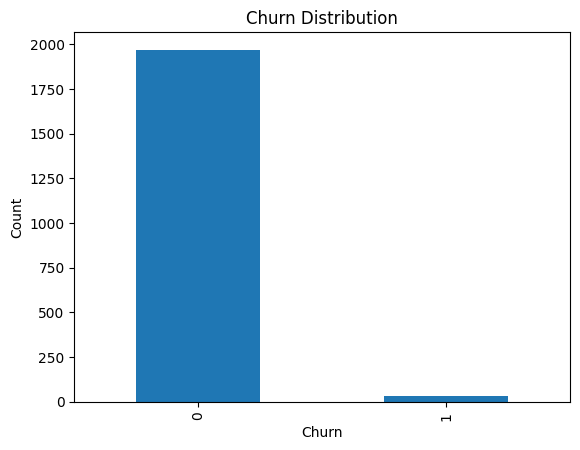

In [7]:
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

# Dataset Understanding

- The dataset contains 2000 rows and 17 columns.
- The target variable is `churn`.
- `1` represents customers who churned.
- `0` represents customers who were retained.
- The dataset contains both categorical and numerical features.
- Categorical features include `region`, `plan_type`, `contract_type`, and `payment_method`.
- Numerical features include `tenure_months`, `monthly_charges_inr`, `avg_login_days_per_month`, `support_tickets_last_90_days`, `payment_delay_days`, `data_usage_gb`, `satisfaction_score`, `last_complaint_days_ago`, `discount_percent`, `autopay_enabled`, and `referral_count`.
- The `customer_id` column is an identifier column and will not be used for prediction.
- Missing value analysis was performed using `isnull().sum()` and no missing values were found in the dataset.
- Statistical summary of numerical features was generated using `describe()`.
- The distribution of the target variable was visualized using a bar chart.

In [11]:
df = df.drop('customer_id', axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [14]:
X = df.drop('churn', axis=1)

y = df['churn']

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 15)
(400, 15)
(1600,)
(400,)


# Data Preprocessing

- The `customer_id` column was removed because it is an identifier column and does not contribute to prediction.
- Categorical columns were encoded using Label Encoding.
- Numerical features were scaled using StandardScaler.
- The dataset was split into training and testing datasets using train_test_split().
- 80% of the data was used for training and 20% for testing.

In [18]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model = Sequential()

# Hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
Dense(16)

<Dense name=dense_2, built=False>

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

# Neural Network Model Building

- A feed-forward neural network was created using TensorFlow/Keras.
- The model consists of:
  - One input layer
  - One hidden layer with 16 neurons
  - ReLU activation function in the hidden layer
  - One output layer with sigmoid activation
- The sigmoid activation function was used because the target variable is binary (`0` or `1`).
- The model was compiled using the Adam optimizer and binary crossentropy loss function.

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1391 - loss: 1.0699 - val_accuracy: 0.2781 - val_loss: 0.8780
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4180 - loss: 0.7730 - val_accuracy: 0.6000 - val_loss: 0.6438
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7273 - loss: 0.5745 - val_accuracy: 0.8500 - val_loss: 0.4932
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8930 - loss: 0.4423 - val_accuracy: 0.9281 - val_loss: 0.3914
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - loss: 0.3516 - val_accuracy: 0.9656 - val_loss: 0.3195
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9758 - loss: 0.2862 - val_accuracy: 0.9719 - val_loss: 0.2693
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.2388 - val_accuracy: 0.9750 - val_loss: 0.2321
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.2031 - val_accuracy: 0.9750 - val_loss:

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9825 - loss: 0.0967
Test Loss: 0.09670060873031616
Test Accuracy: 0.9825000166893005


In [27]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[393   0]
 [  7   0]]


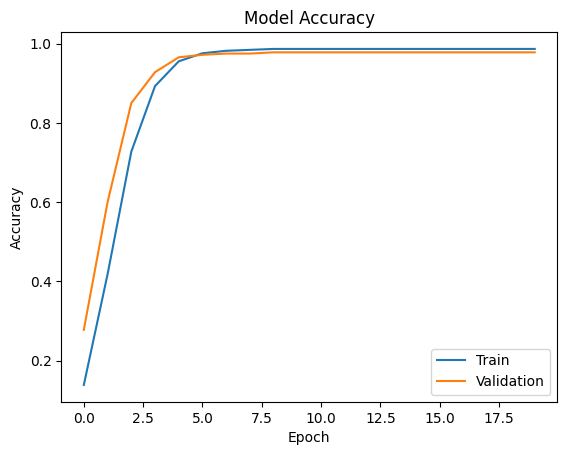

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

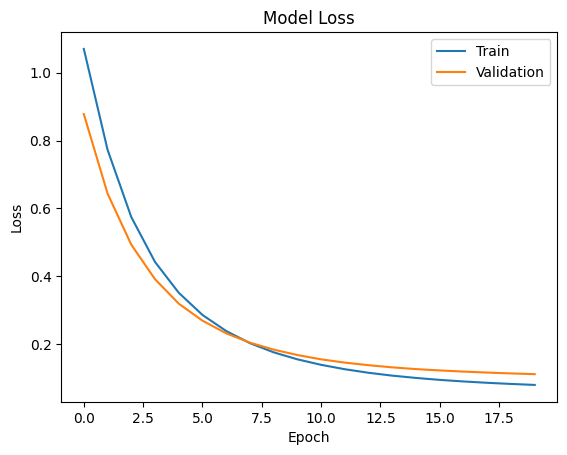

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# Training and Evaluation

- The neural network model was trained using the training dataset.
- The model was trained for 20 epochs with a batch size of 32.
- Training and validation accuracy improved during training.
- The trained model was evaluated using the testing dataset.
- Test accuracy and test loss were calculated.
- A confusion matrix was generated to evaluate prediction performance.
- Accuracy and loss graphs were plotted to visualize the learning behavior of the model.

In [31]:
model2 = Sequential()

model2.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, accuracy2 = model2.evaluate(X_test, y_test)

print("Experiment 2 Accuracy:", accuracy2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0766  
Experiment 2 Accuracy: 0.9825000166893005


In [32]:
model3 = Sequential()

model3.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, accuracy3 = model3.evaluate(X_test, y_test)

print("Experiment 3 Accuracy:", accuracy3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0846  
Experiment 3 Accuracy: 0.9825000166893005


In [33]:
import pandas as pd

comparison = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Neurons': [16, 32, 16],
    'Epochs': [20, 20, 50],
    'Accuracy': [
        accuracy,
        accuracy2,
        accuracy3
    ]
})

comparison

,Experiment,Neurons,Epochs,Accuracy
0,Experiment 1,16,20,0.9825
1,Experiment 2,32,20,0.9825
2,Experiment 3,16,50,0.9825


In [34]:
comparison.to_csv('model_comparison_table.csv', index=False)

# Hyperparameter Experimentation

- Multiple neural network configurations were tested to analyze model performance.
- Different numbers of neurons and epochs were used in different experiments.
- Experiment 1 used 16 neurons and 20 epochs.
- Experiment 2 used 32 neurons and 20 epochs.
- Experiment 3 used 16 neurons and 50 epochs.
- Model performance was compared using testing accuracy.
- A comparison table was created to summarize the results of all experiments.

# Final Reflection

## Role of Weights and Biases

Weights help the neural network learn the importance of input features. Biases help shift the activation function and improve the flexibility of the model during learning.

## Importance of Activation Function

Activation functions allow the neural network to learn complex and non-linear patterns from the dataset. Without activation functions, the neural network behaves like a simple linear model.

## Effect of Learning Rate

If the learning rate is too high, the model may skip the optimal solution and training may become unstable. If the learning rate is too low, the model learns very slowly and training takes more time.

## Underfitting and Overfitting

The model performance was analyzed using training and validation accuracy. If training accuracy becomes very high while testing accuracy remains low, the model may be overfitting. If both accuracies remain low, the model may be underfitting.